In [3]:
!pip install giotto-tda ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:00


In [4]:
# %%
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import ruptures as rpt

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, PersistenceLandscape

In [5]:
np.random.seed(42)

# %% [markdown]
# ## 1) Simulate a regime-switching Lorenz system
#
# We keep the system itself fixed within each regime and switch rho.
# The pipeline only sees the scalar observation x(t).

# %%
def lorenz_rhs(state, sigma, beta, rho):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz], dtype=np.float64)

def rk4_step(state, dt, sigma, beta, rho):
    k1 = lorenz_rhs(state, sigma, beta, rho)
    k2 = lorenz_rhs(state + 0.5 * dt * k1, sigma, beta, rho)
    k3 = lorenz_rhs(state + 0.5 * dt * k2, sigma, beta, rho)
    k4 = lorenz_rhs(state + dt * k3, sigma, beta, rho)
    return state + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

def simulate_switching_lorenz(
    rhos,
    segment_lengths,
    dt=0.01,
    sigma=10.0,
    beta=8.0 / 3.0,
    x0=(1.0, 1.0, 1.0),
    obs_noise_std=0.0,
):
    if len(rhos) != len(segment_lengths):
        raise ValueError("rhos and segment_lengths must have the same length.")

    states = []
    regime_ids = []
    rho_series = []

    state = np.array(x0, dtype=np.float64)

    for reg_id, (rho, L) in enumerate(zip(rhos, segment_lengths)):
        for _ in range(L):
            states.append(state.copy())
            regime_ids.append(reg_id)
            rho_series.append(rho)
            state = rk4_step(state, dt, sigma, beta, rho)

    states = np.asarray(states, dtype=np.float64)
    observed_x = states[:, 0].copy()

    if obs_noise_std > 0:
        observed_x = observed_x + np.random.normal(0.0, obs_noise_std, size=len(observed_x))

    return states, observed_x, np.asarray(regime_ids, dtype=int), np.asarray(rho_series, dtype=np.float64)

# Three regimes with known boundaries.
rhos = [28.0, 45.0, 70.0]
segment_lengths = [2500, 2500, 2500]
dt = 0.01

states, x_obs, regime_ids, rho_series = simulate_switching_lorenz(
    rhos=rhos,
    segment_lengths=segment_lengths,
    dt=dt,
    obs_noise_std=0.00,
)

In [6]:
n = len(x_obs)
true_boundaries = np.cumsum(segment_lengths)[:-1]
time = np.arange(n) * dt

# Standardize the observed scalar series for a fair TDA pipeline.
x_obs_std = StandardScaler().fit_transform(x_obs.reshape(-1, 1)).ravel()

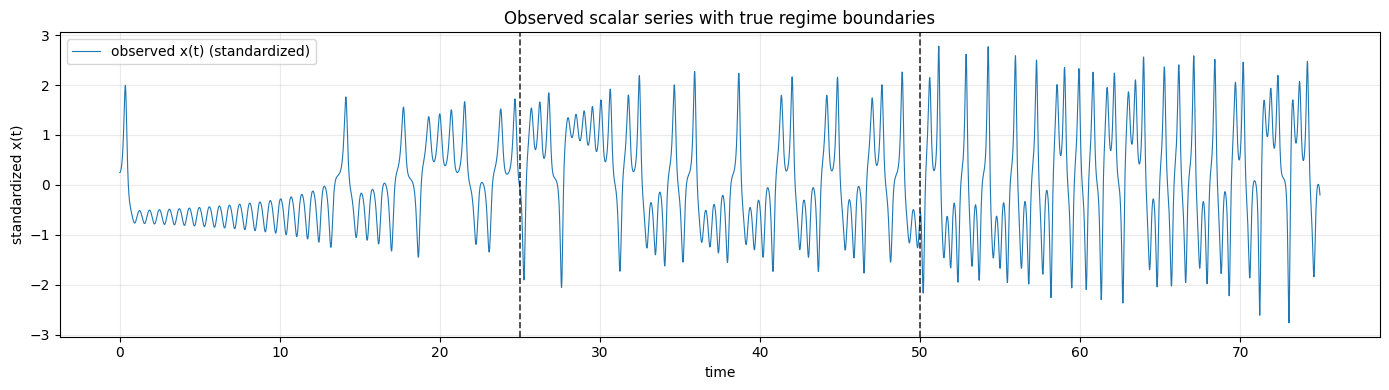

In [7]:
# %%
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, x_obs_std, lw=0.8, label="observed x(t) (standardized)")
for b in true_boundaries:
    ax.axvline(b * dt, color="black", ls="--", lw=1.2, alpha=0.8)
ax.set_title("Observed scalar series with true regime boundaries")
ax.set_xlabel("time")
ax.set_ylabel("standardized x(t)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

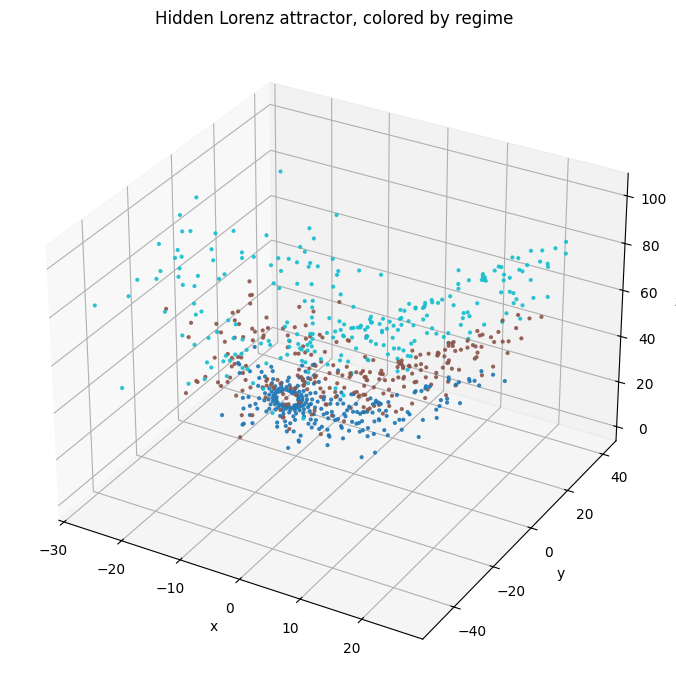

In [8]:
# %%
# 3D view of the full hidden Lorenz state, colored by regime.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

sample = np.arange(0, len(states), 10)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    states[sample, 0],
    states[sample, 1],
    states[sample, 2],
    c=regime_ids[sample],
    cmap="tab10",
    s=4,
    alpha=0.85,
)
ax.set_title("Hidden Lorenz attractor, colored by regime")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()

In [9]:
# %% [markdown]
# ## 2) Rolling windows and Takens embeddings
#
# We compute a point cloud per window, then extract TDA features from each window.

# %%
def make_sliding_windows(values, window_size, stride):
    values = np.asarray(values, dtype=np.float32).reshape(-1)
    windows = []
    starts = []
    for start in range(0, len(values) - window_size + 1, stride):
        windows.append(values[start : start + window_size])
        starts.append(start)
    return np.asarray(windows, dtype=np.float32), np.asarray(starts, dtype=int)

def takens_embedding_1d(series_1d, tau, m):
    x = np.asarray(series_1d, dtype=np.float32).reshape(-1)
    if len(x) <= (m - 1) * tau:
        raise ValueError("Window too short for requested Takens embedding.")

    embedded = []
    for i in range((m - 1) * tau, len(x)):
        embedded.append([x[i - j * tau] for j in range(m)])
    return np.asarray(embedded, dtype=np.float32)

def window_regime_labels(window_centers, boundaries):
    return np.searchsorted(boundaries, window_centers, side="right").astype(int)

def plot_point_cloud_3d(pc, title):
    pc = np.asarray(pc)
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(pc[:, 0], pc[:, 1], pc[:, 2], lw=0.9)
    ax.set_title(title)
    ax.set_xlabel("x(t)")
    ax.set_ylabel("x(t-τ)")
    ax.set_zlabel("x(t-2τ)")
    plt.tight_layout()
    plt.show()

In [10]:
def plot_diagram(diagram, title):
    d = np.asarray(diagram)
    if d.ndim != 2 or d.shape[1] < 3:
        print("Unexpected diagram shape:", d.shape)
        return

    births = d[:, 0].astype(float)
    deaths = d[:, 1].astype(float)
    dims = d[:, 2].astype(int)

    finite_deaths = deaths[np.isfinite(deaths)]
    if len(finite_deaths) == 0:
        print("No finite deaths in diagram.")
        return

    max_finite = float(np.max(finite_deaths))
    deaths_plot = deaths.copy()
    deaths_plot[~np.isfinite(deaths_plot)] = max_finite * 1.05

    lim = float(max(np.max(births), np.max(deaths_plot)) * 1.05)

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for dim in sorted(np.unique(dims)):
        mask = dims == dim
        ax.scatter(births[mask], deaths_plot[mask], s=20, alpha=0.85, label=f"H{dim}")

    ax.plot([0, lim], [0, lim], "--", color="gray", lw=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("birth")
    ax.set_ylabel("death")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [11]:
class TopologyFeatureExtractor:
    def __init__(
        self,
        homology_dimensions=(0, 1),
        max_edge_length=10.0,
        n_layers=5,
        n_bins=50,
        normalize_entropy=True,
        nan_fill_value=0.0,
        n_jobs=-1,
    ):
        self.vr = VietorisRipsPersistence(
            homology_dimensions=list(homology_dimensions),
            max_edge_length=max_edge_length,
            n_jobs=n_jobs,
        )
        self.pe = PersistenceEntropy(
            normalize=normalize_entropy,
            nan_fill_value=nan_fill_value,
            n_jobs=n_jobs,
        )
        self.pl = PersistenceLandscape(
            n_layers=n_layers,
            n_bins=n_bins,
            n_jobs=n_jobs,
        )

    def fit_transform(self, point_clouds):
        diagrams = self.vr.fit_transform(point_clouds)
        pe = self.pe.fit_transform(diagrams).astype(np.float32)
        pl = self.pl.fit_transform(diagrams).astype(np.float32).reshape(len(point_clouds), -1)
        return diagrams, pe, pl

def diagram_summary_features(diagrams):
    """
    Additional summary statistics from persistence diagrams.
    These are still topological features, just more compact ones.
    """
    out = []
    for d in diagrams:
        row = []
        for q in [0, 1]:
            sub = d[d[:, 2] == q]
            lifetimes = sub[:, 1] - sub[:, 0]
            lifetimes = lifetimes[np.isfinite(lifetimes)]
            if len(lifetimes) == 0:
                row.extend([0.0, 0.0, 0.0, 0.0])
            else:
                row.extend([
                    float(len(lifetimes)),
                    float(np.sum(lifetimes)),
                    float(np.mean(lifetimes)),
                    float(np.max(lifetimes)),
                ])
        out.append(row)
    return np.asarray(out, dtype=np.float32)

In [12]:
# Rolling-window parameters.
window_size = 300
stride = 40
tau = 8
m = 3
point_subsample = 2

windows, starts = make_sliding_windows(x_obs_std, window_size=window_size, stride=stride)
window_centers = starts + window_size // 2
window_labels = window_regime_labels(window_centers, true_boundaries)

# Build a point cloud for each window via Takens embedding.
point_clouds = []
for w in windows:
    emb = takens_embedding_1d(w, tau=tau, m=m)
    emb = emb[::point_subsample]
    point_clouds.append(emb)

point_clouds = np.asarray(point_clouds, dtype=np.float32)
point_clouds.shape

# %% [markdown]
# ## 3) Extract topological features window by window

# %%
extractor = TopologyFeatureExtractor(
    homology_dimensions=(0, 1),
    max_edge_length=10.0,
    n_layers=5,
    n_bins=50,
    normalize_entropy=True,
    nan_fill_value=0.0,
    n_jobs=-1,
)

diagrams, pe, pl = extractor.fit_transform(point_clouds)
diag_stats = diagram_summary_features(diagrams)

In [13]:
# Combine all TDA features.
X_topo = np.concatenate([pe, pl, diag_stats], axis=1)

# Standardize features for detection.
Xz = StandardScaler().fit_transform(X_topo)

# Low-dimensional view for plotting.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(Xz)

# %%
print("Point clouds:", point_clouds.shape)
print("Diagrams:", diagrams.shape)
print("Persistence entropy:", pe.shape)
print("Persistence landscape:", pl.shape)
print("Combined TDA features:", X_topo.shape)
print("Explained variance by PC1/PC2:", pca.explained_variance_ratio_)

Point clouds: (181, 142, 3)
Diagrams: (181, 220, 3)
Persistence entropy: (181, 2)
Persistence landscape: (181, 500)
Combined TDA features: (181, 510)
Explained variance by PC1/PC2: [0.39166185 0.20691235]


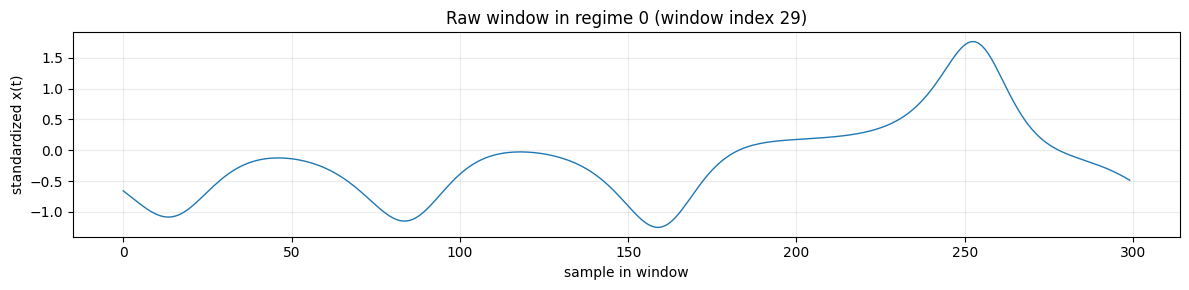

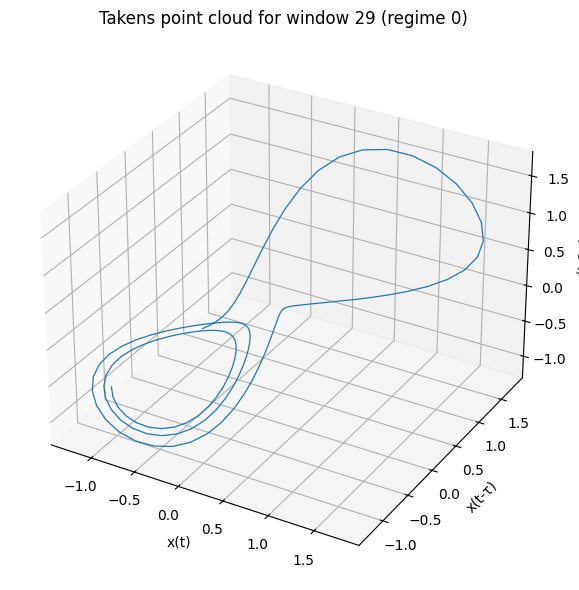

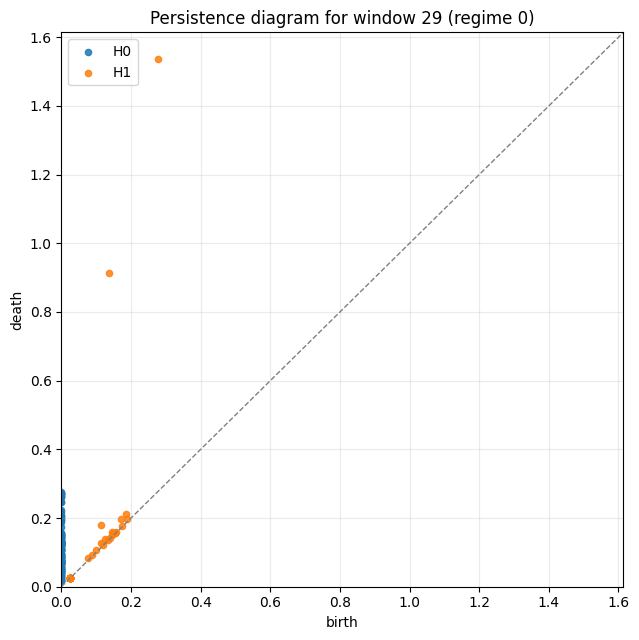

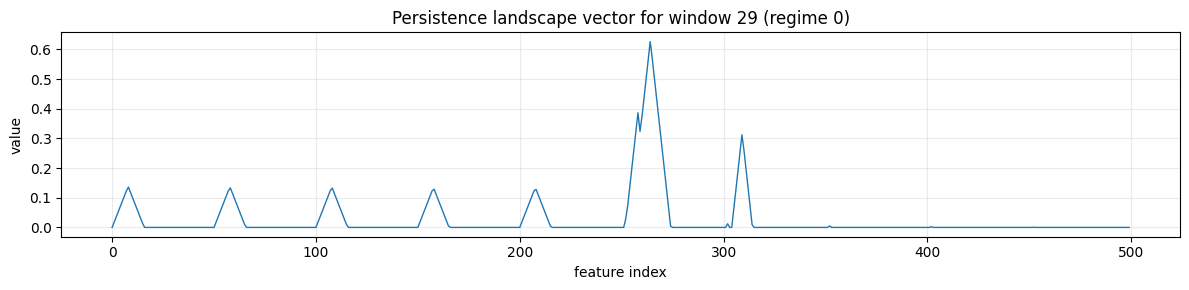

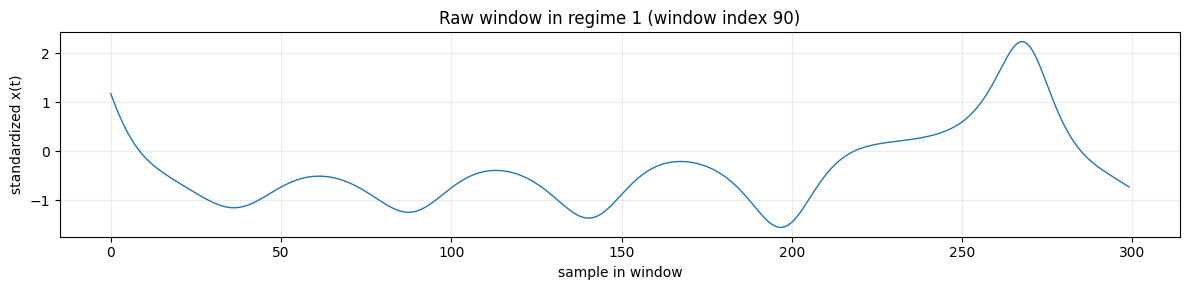

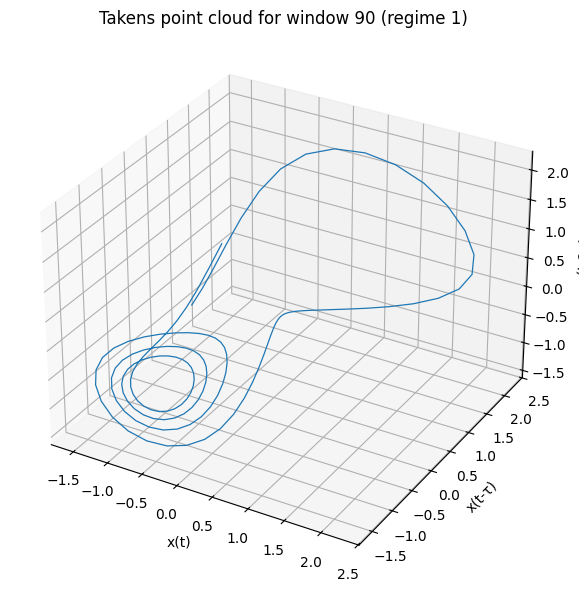

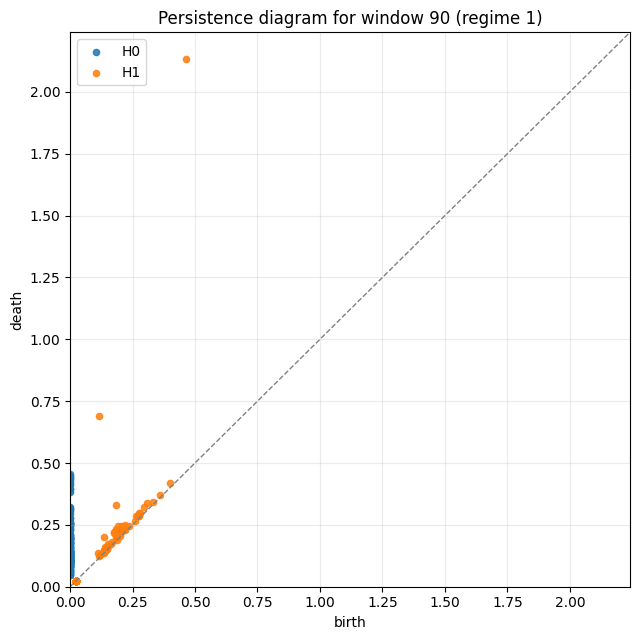

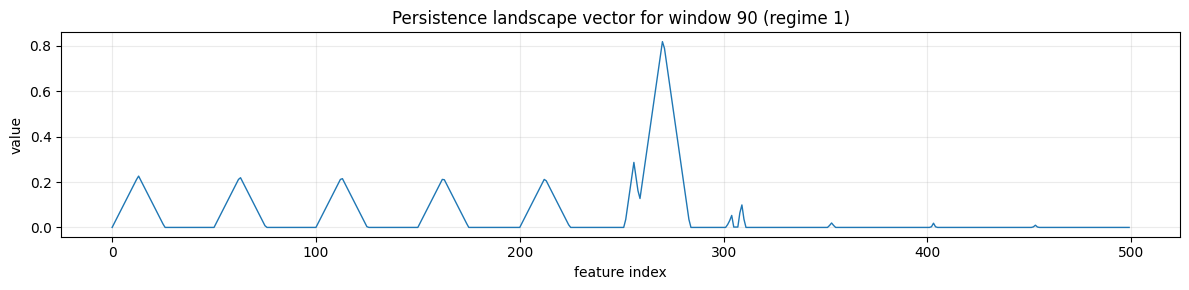

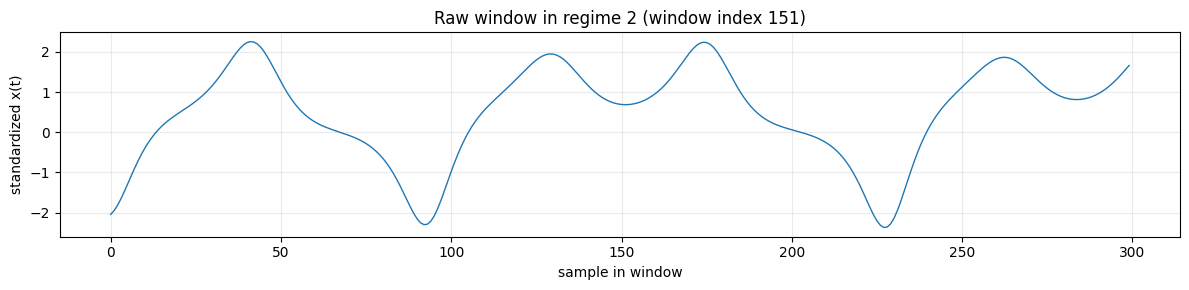

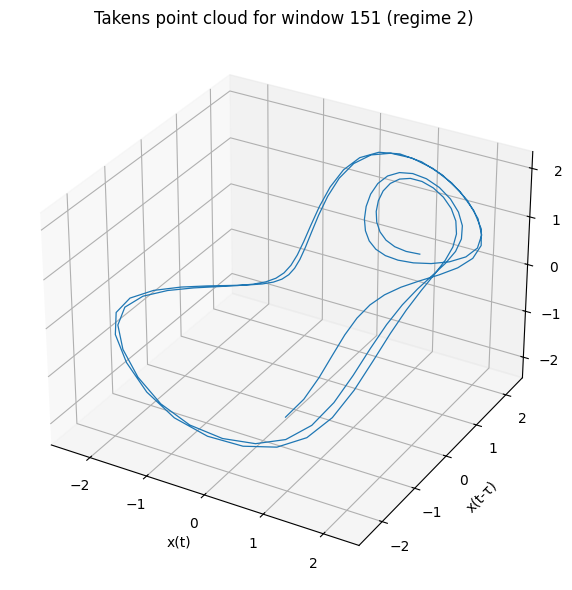

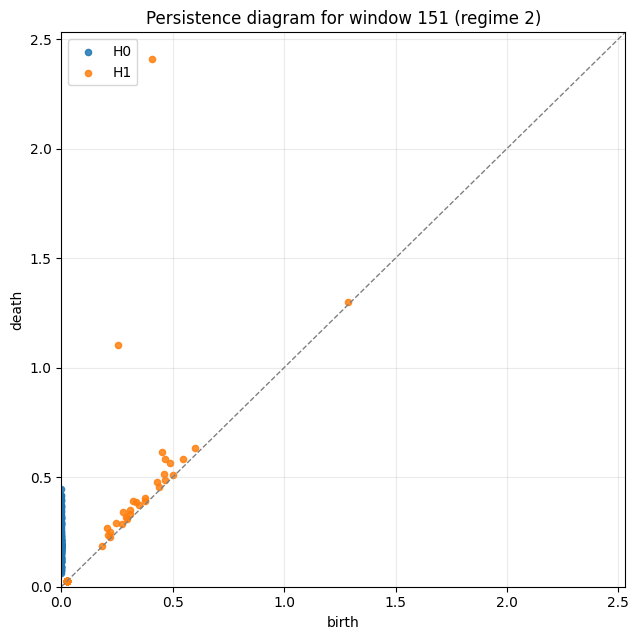

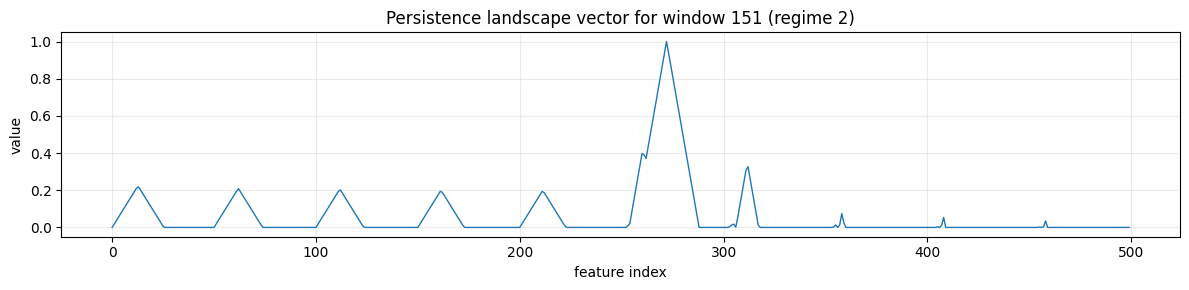

In [14]:
# %% [markdown]
# ## 4) Inspect representative windows from each regime

# %%
def nearest_window_index(target_regime, center_choice="middle"):
    idx = np.where(window_labels == target_regime)[0]
    if len(idx) == 0:
        raise ValueError(f"No windows found for regime {target_regime}")
    if center_choice == "middle":
        return idx[len(idx) // 2]
    return idx[0]

representative_indices = [
    nearest_window_index(0),
    nearest_window_index(1),
    nearest_window_index(2),
]

for wi in representative_indices:
    w = windows[wi]
    pc = point_clouds[wi]
    diag = diagrams[wi]
    reg = window_labels[wi]

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(w, lw=1)
    ax.set_title(f"Raw window in regime {reg} (window index {wi})")
    ax.set_xlabel("sample in window")
    ax.set_ylabel("standardized x(t)")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    plot_point_cloud_3d(pc, title=f"Takens point cloud for window {wi} (regime {reg})")
    plot_diagram(diag, title=f"Persistence diagram for window {wi} (regime {reg})")

    # Plot a flattened landscape vector for comparison.
    landscape_vec = pl[wi]
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(landscape_vec, lw=1)
    ax.set_title(f"Persistence landscape vector for window {wi} (regime {reg})")
    ax.set_xlabel("feature index")
    ax.set_ylabel("value")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [15]:
# %% [markdown]
# ## 5) Change-point detection from TDA features

# %%
# Two ways to detect regime changes:
# 1) explicit number of change points (Binseg)
# 2) penalized search (PELT)

n_true_changes = len(true_boundaries)
detector_binseg = rpt.Binseg(model="rbf", min_size=5, jump=1).fit(Xz)
bkps_binseg = detector_binseg.predict(n_bkps=n_true_changes)

detector_pelt = rpt.Pelt(model="rbf", min_size=5, jump=1).fit(Xz)
bkps_pelt = detector_pelt.predict(pen=10)

def bkp_to_window_center(bkps, centers):
    # ruptures returns segment end indices, the last one is len(signal)
    bkps = [b for b in bkps if b < len(centers)]
    return centers[np.asarray(bkps) - 1]

detected_centers_binseg = bkp_to_window_center(bkps_binseg, window_centers)
detected_centers_pelt = bkp_to_window_center(bkps_pelt, window_centers)

print("True change points (sample index):", true_boundaries)
print("Detected by Binseg (sample index):", detected_centers_binseg)
print("Detected by PELT   (sample index):", detected_centers_pelt)

True change points (sample index): [2500 5000]
Detected by Binseg (sample index): [1150 2350]
Detected by PELT   (sample index): [1150 2350]


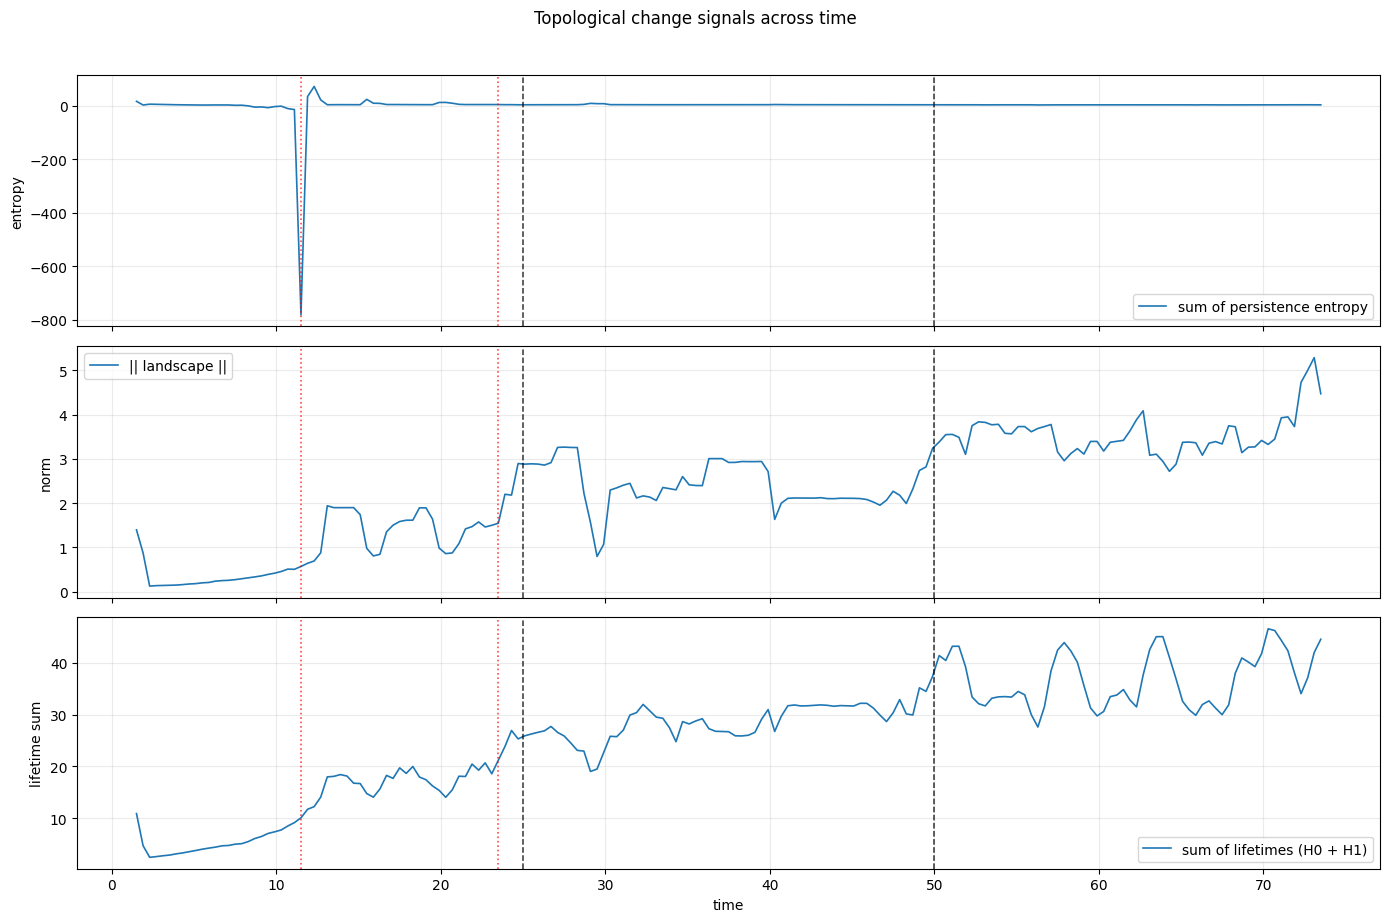

In [16]:
# %%
# Plot several topological signals directly.
entropy_total = pe.sum(axis=1)
landscape_norm = np.linalg.norm(pl, axis=1)
diag_lifetime_sum = diag_stats[:, 1] + diag_stats[:, 5]  # H0 sum + H1 sum

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(window_centers * dt, entropy_total, lw=1.2, label="sum of persistence entropy")
axes[0].set_ylabel("entropy")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(window_centers * dt, landscape_norm, lw=1.2, label="|| landscape ||")
axes[1].set_ylabel("norm")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(window_centers * dt, diag_lifetime_sum, lw=1.2, label="sum of lifetimes (H0 + H1)")
axes[2].set_ylabel("lifetime sum")
axes[2].set_xlabel("time")
axes[2].grid(alpha=0.25)
axes[2].legend()

for ax in axes:
    for b in true_boundaries:
        ax.axvline(b * dt, color="black", ls="--", lw=1.1, alpha=0.8)
    for b in detected_centers_binseg:
        ax.axvline(b * dt, color="red", ls=":", lw=1.2, alpha=0.7)

fig.suptitle("Topological change signals across time", y=1.02)
plt.tight_layout()
plt.show()

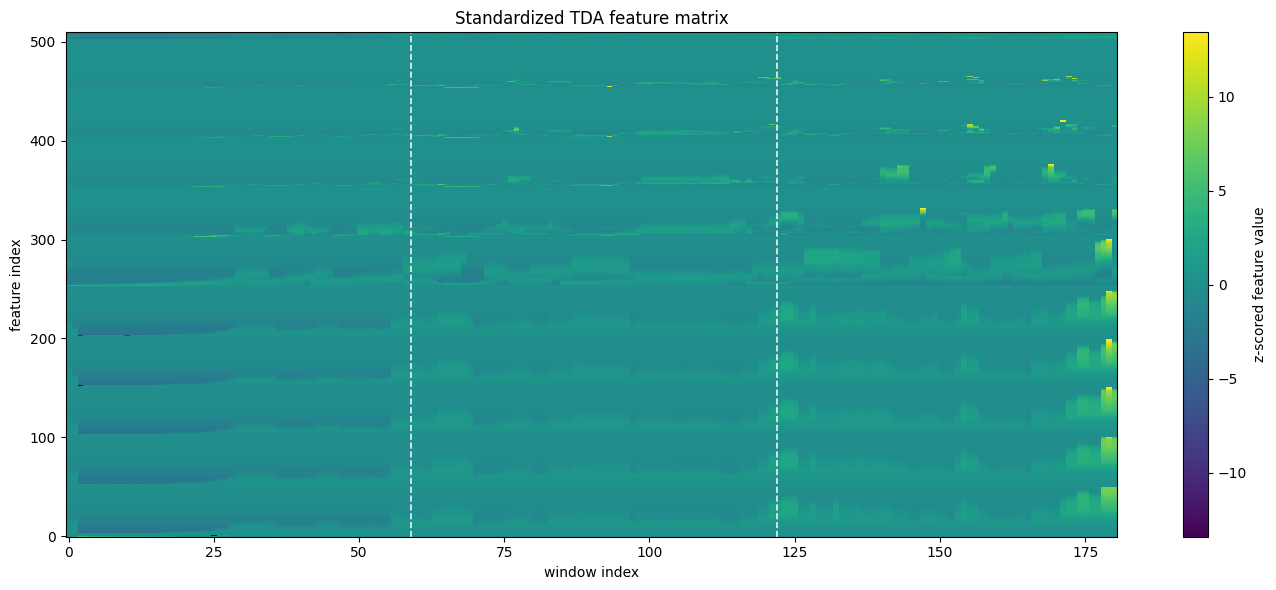

In [17]:
# %%
# Heatmap view of all standardized TDA features.
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    Xz.T,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    interpolation="nearest",
)
ax.set_title("Standardized TDA feature matrix")
ax.set_xlabel("window index")
ax.set_ylabel("feature index")

# Overlay true regime boundaries in window coordinates.
for b in true_boundaries:
    win_idx = np.searchsorted(window_centers, b)
    ax.axvline(win_idx, color="white", ls="--", lw=1.2, alpha=0.9)

plt.colorbar(im, ax=ax, label="z-scored feature value")
plt.tight_layout()
plt.show()

In [18]:
# %% [markdown]
# ## 6) Unsupervised clustering as a regime proxy
#
# This is optional, but useful to show that the topological features
# separate the regimes without seeing labels.

# %%
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(Xz)

ari = adjusted_rand_score(window_labels, cluster_labels)
nmi = normalized_mutual_info_score(window_labels, cluster_labels)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

Adjusted Rand Index: 0.463
Normalized Mutual Information: 0.562


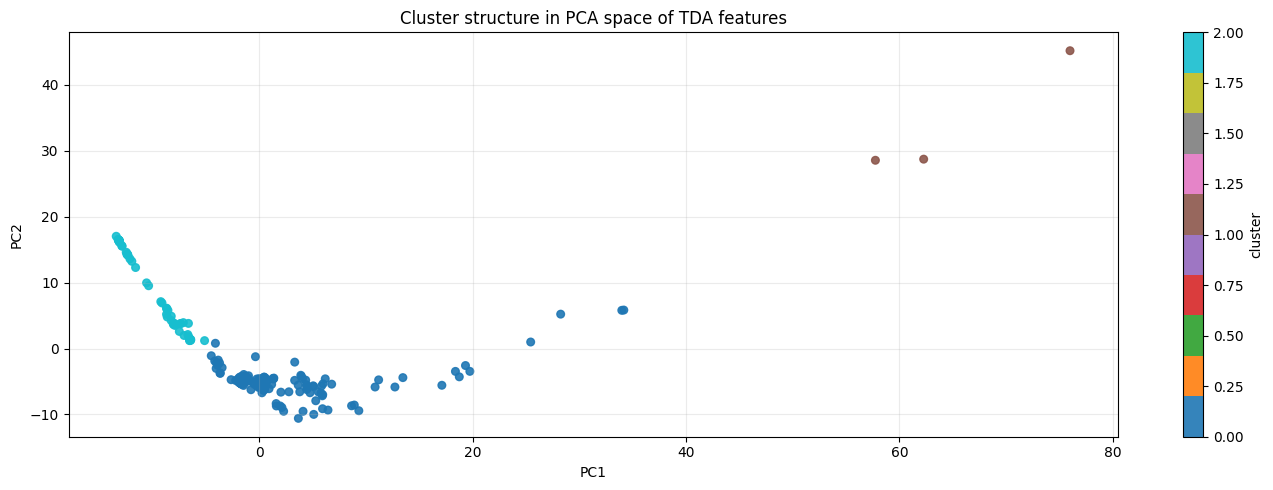

In [19]:
# %%
fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=30,
    alpha=0.9,
)
ax.set_title("Cluster structure in PCA space of TDA features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
plt.colorbar(sc, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

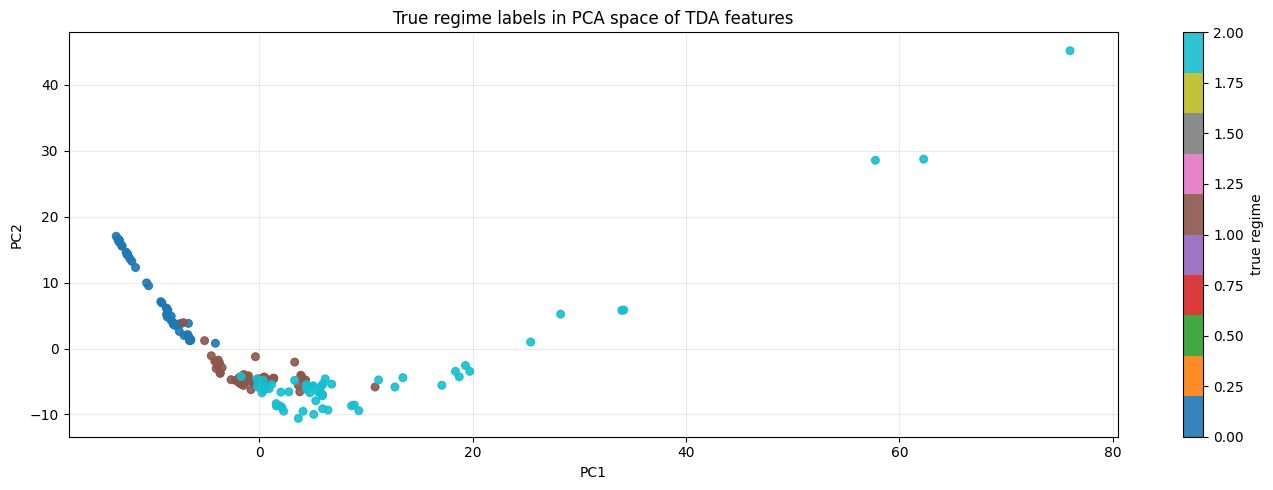

In [20]:
# %%
fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=window_labels,
    cmap="tab10",
    s=30,
    alpha=0.9,
)
ax.set_title("True regime labels in PCA space of TDA features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
plt.colorbar(sc, ax=ax, label="true regime")
plt.tight_layout()
plt.show()

In [21]:
# %% [markdown]
# ## 7) Compare detected regimes against the ground truth

# %%
# Convert window-level labels to a DataFrame for inspection.
summary = pd.DataFrame(
    {
        "window_index": np.arange(len(window_centers)),
        "center_sample": window_centers,
        "center_time": window_centers * dt,
        "true_regime": window_labels,
        "pc1": X_pca[:, 0],
        "pc2": X_pca[:, 1],
        "entropy_total": entropy_total,
        "landscape_norm": landscape_norm,
        "diag_lifetime_sum": diag_lifetime_sum,
        "cluster_label": cluster_labels,
    }
)

summary.head()

,window_index,center_sample,center_time,true_regime,pc1,pc2,entropy_total,landscape_norm,diag_lifetime_sum,cluster_label
0,0,150,1.5,0,-4.119857,0.793910,15.878240,1.396977,10.914201,0
1,1,190,1.9,0,-6.647943,3.807957,2.143153,0.875607,4.724530,2
2,2,230,2.3,0,-13.419455,17.014872,5.240107,0.126879,2.483279,2
3,3,270,2.7,0,-13.193793,16.478764,4.655929,0.137308,2.613842,2
4,4,310,3.1,0,-13.173633,16.436583,4.099902,0.140727,2.779250,2



--- Around true boundary at sample 2500 ---


,window_index,center_sample,center_time,true_regime,pc1,pc2,entropy_total,landscape_norm,diag_lifetime_sum,cluster_label
56,56,2390,23.9,0,-0.938710,-4.836688,3.416834,2.200209,23.839319,0
57,57,2430,24.3,0,-0.694489,-5.041953,3.408007,2.181699,26.937027,0
58,58,2470,24.7,0,-0.052899,-5.081002,2.979558,2.893993,25.314203,0
59,59,2510,25.1,1,-0.069852,-4.786564,3.128155,2.880390,25.902601,0
60,60,2550,25.5,1,-0.008641,-4.751335,3.085898,2.887764,26.255463,0
61,61,2590,25.9,1,-0.037835,-4.575718,3.143169,2.881963,26.578743,0
62,62,2630,26.3,1,-1.018155,-4.130415,3.120665,2.858997,26.867212,0



--- Around true boundary at sample 5000 ---


,window_index,center_sample,center_time,true_regime,pc1,pc2,entropy_total,landscape_norm,diag_lifetime_sum,cluster_label
119,119,4910,49.1,1,3.642003,-5.544733,3.224855,2.737318,35.163834,0
120,120,4950,49.5,1,3.789420,-6.562675,3.039226,2.818917,34.474037,0
121,121,4990,49.9,1,10.849802,-5.836164,2.831187,3.236992,37.385334,0
122,122,5030,50.3,2,12.710669,-5.835899,2.885673,3.380782,41.389347,0
123,123,5070,50.7,2,19.325735,-2.581705,2.920935,3.546756,40.434952,0
124,124,5110,51.1,2,19.735888,-3.462786,3.010387,3.551787,43.172073,0
125,125,5150,51.5,2,17.110979,-5.574111,2.987597,3.486657,43.183666,0


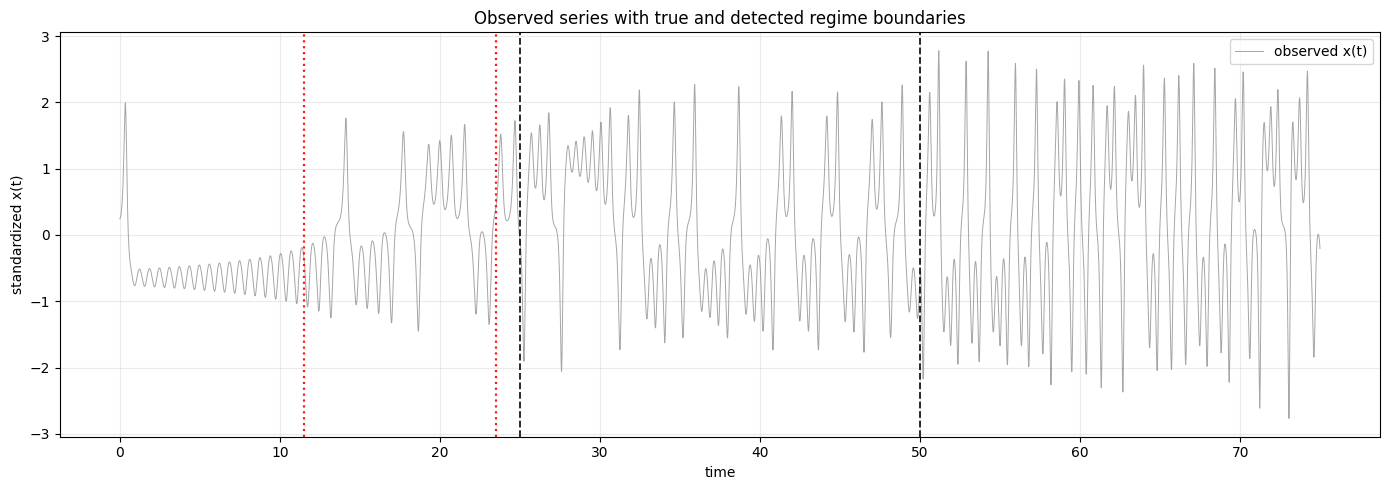

In [22]:
# %%
# Show the first few rows around each true boundary.
for b in true_boundaries:
    idx = np.searchsorted(window_centers, b)
    lo = max(0, idx - 3)
    hi = min(len(summary), idx + 4)
    print(f"\n--- Around true boundary at sample {b} ---")
    display(summary.iloc[lo:hi])

# %% [markdown]
# ## 8) A compact visual summary

# %%
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time, x_obs_std, lw=0.7, color="gray", alpha=0.7, label="observed x(t)")
for b in true_boundaries:
    ax.axvline(b * dt, color="black", ls="--", lw=1.3, alpha=0.9)
for b in detected_centers_binseg:
    ax.axvline(b * dt, color="red", ls=":", lw=1.6, alpha=0.9)
ax.set_title("Observed series with true and detected regime boundaries")
ax.set_xlabel("time")
ax.set_ylabel("standardized x(t)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# %%
# Final numeric summary
print("True change points:", true_boundaries)
print("Binseg detected change points:", detected_centers_binseg)
print("PELT detected change points:", detected_centers_pelt)
print(f"ARI (clusters vs true regimes): {ari:.3f}")
print(f"NMI (clusters vs true regimes): {nmi:.3f}")

True change points: [2500 5000]
Binseg detected change points: [1150 2350]
PELT detected change points: [1150 2350]
ARI (clusters vs true regimes): 0.463
NMI (clusters vs true regimes): 0.562
